# Kepler CSV + `tum_uzay_copleri` — kısa EDA

Feature üretmeden önce: dağılımlar, frekanslar, grup bazlı özetler.

**Kepler dosyaları — iki olası konum (farklı şema):**
- `data/processed/*_combined.csv` — `dat_to_csv.py` çıktısı: `dataset`, `source_file`, `obs_index` + Kepler sütunları (tercih edilen).
- Proje kökündeki `*_combined.csv` — eski biçim: yalnızca `Dosya Adı` + Kepler (ek meta sütun yok).

Notebook önce `data/processed/` dosyasını kullanır; yoksa kök dosyayı okuyup `dataset` / `source_file` / `obs_index` türetir.

**`tum_uzay_copleri.csv`:** TLE/snapshot boru hattından gelen anlık konum/hız; Kepler zaman serisiyle **ortak NORAD / epoch anahtarı olmadan birleştirilmez** — ayrı EDA bölümü olarak kalır.

**Gerekli:** `tum_uzay_copleri.csv` (kök). Kepler için yukarıdaki yollardan biri.

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Notebook'u proje kökünden veya notebooks/ altından çalıştırabilirsiniz
ROOT = Path.cwd().resolve()
if not (ROOT / "sat_combined.csv").exists() and (ROOT.parent / "sat_combined.csv").exists():
    ROOT = ROOT.parent

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 20)
print("PROJECT_ROOT =", ROOT)

PROJECT_ROOT = C:\Users\samet\OneDrive\Belgeler\GitHub\SpaceDebrisTrackingModel


## 1) Kepler birleşik CSV'ler

- Veri seti etiketi (`dataset`) ve kaynak dosya (`source_file`); gerekirse satır içi sıra (`obs_index`)
- Sayısal sütunlar için `describe`
- Seçili değişkenler için histogramlar

In [16]:
KEPLER_NUM = [
    "time_days",
    "semi_major_axis_km",
    "eccentricity",
    "inclination_deg",
    "raan_deg",
    "arg_perigee_deg",
    "mean_anomaly_deg",
]
SOURCE_COL = "source_file"
PROCESSED = ROOT / "data" / "processed"


def _dataset_label_from_filename(csv_name: str) -> str:
    if csv_name.startswith("sat"):
        return "sat"
    if "train" in csv_name:
        return "deb_train"
    if "test" in csv_name:
        return "deb_test"
    return csv_name.split("_")[0]


def normalize_legacy_kepler(df: pd.DataFrame, dataset_label: str) -> pd.DataFrame:
    """Kök dizindeki eski şema: Dosya Adı → source_file; dataset ve obs_index eklenir."""
    out = df.copy()
    if "Dosya Adı" in out.columns:
        out = out.rename(columns={"Dosya Adı": "source_file"})
    if "dataset" not in out.columns:
        out.insert(0, "dataset", dataset_label)
    if "obs_index" not in out.columns:
        out.insert(2, "obs_index", out.groupby("source_file", sort=False).cumcount())
    return out


def load_kepler(csv_name: str) -> pd.DataFrame:
    """Önce data/processed/, yoksa kök; eski şemayı tek forma getirir."""
    path_proc = PROCESSED / csv_name
    path_root = ROOT / csv_name
    if path_proc.exists():
        print(f"[Kepler] {path_proc}")
        return pd.read_csv(path_proc, encoding="utf-8-sig")
    if path_root.exists():
        print(f"[Kepler] {path_root} (legacy → dataset/source_file/obs_index türetildi)")
        df = pd.read_csv(path_root, encoding="utf-8-sig")
        return normalize_legacy_kepler(df, _dataset_label_from_filename(csv_name))
    raise FileNotFoundError(f"Bulunamadı: {path_proc} veya {path_root}")


sat = load_kepler("sat_combined.csv")
deb_tr = load_kepler("deb_train_combined.csv")
deb_te = load_kepler("deb_test_combined.csv")

print("sat sütunları:", list(sat.columns))
display(sat.head(2))

for label, df in [("sat", sat), ("deb_train", deb_tr), ("deb_test", deb_te)]:
    print(
        f"{label}: {len(df):,} satır | "
        f"{df[SOURCE_COL].nunique()} benzersiz {SOURCE_COL}"
    )

[Kepler] C:\Users\samet\OneDrive\Belgeler\GitHub\SpaceDebrisTrackingModel\data\processed\sat_combined.csv
[Kepler] C:\Users\samet\OneDrive\Belgeler\GitHub\SpaceDebrisTrackingModel\data\processed\deb_train_combined.csv
[Kepler] C:\Users\samet\OneDrive\Belgeler\GitHub\SpaceDebrisTrackingModel\data\processed\deb_test_combined.csv
sat sütunları: ['dataset', 'source_file', 'obs_index', 'time_days', 'semi_major_axis_km', 'eccentricity', 'inclination_deg', 'raan_deg', 'arg_perigee_deg', 'mean_anomaly_deg']


,dataset,source_file,obs_index,time_days,semi_major_axis_km,eccentricity,inclination_deg,raan_deg,arg_perigee_deg,mean_anomaly_deg
0,sat,elesat001.dat,0,-7305.0,42257.78,0.099766,8.1313,20.6660,112.9348,299.4938
1,sat,elesat001.dat,1,-7295.0,42257.53,0.099696,8.1038,18.8144,113.1322,299.3533


sat: 109,600 satır | 100 benzersiz source_file
deb_train: 751 satır | 100 benzersiz source_file
deb_test: 751 satır | 100 benzersiz source_file


In [17]:
print("--- sat: kaynak dosya başına satır sayısı (üst 15) ---")
display(sat[SOURCE_COL].value_counts().head(15))

print("--- deb_train / deb_test: benzersiz dosya sayısı ---")
print("deb_train:", deb_tr[SOURCE_COL].nunique(), "| deb_test:", deb_te[SOURCE_COL].nunique())

--- sat: kaynak dosya başına satır sayısı (üst 15) ---


source_file
elesat001.dat    1096
elesat002.dat    1096
elesat003.dat    1096
elesat004.dat    1096
elesat005.dat    1096
elesat006.dat    1096
elesat007.dat    1096
elesat008.dat    1096
elesat009.dat    1096
elesat010.dat    1096
elesat011.dat    1096
elesat012.dat    1096
elesat013.dat    1096
elesat014.dat    1096
elesat015.dat    1096
Name: count, dtype: int64

--- deb_train / deb_test: benzersiz dosya sayısı ---
deb_train: 100 | deb_test: 100


In [18]:
print("sat — describe")
display(sat[KEPLER_NUM].describe().T)

print("deb_train — describe")
display(deb_tr[KEPLER_NUM].describe().T)

print("deb_test — describe")
display(deb_te[KEPLER_NUM].describe().T)

sat — describe


,count,mean,std,min,25%,50%,75%,max
time_days,109600.0,-1830.000000,3163.892592,-7305.000000,-4567.500000,-1830.000000,907.500000,3645.000000
semi_major_axis_km,109600.0,42254.834912,3.857942,42244.510000,42251.980000,42254.840000,42257.610000,42265.600000
eccentricity,109600.0,0.053018,0.027985,0.002761,0.029555,0.053602,0.073729,0.110802
inclination_deg,109600.0,11.635586,5.210860,0.086200,7.699875,11.925650,15.320825,24.508400
raan_deg,109600.0,180.691204,103.877196,0.003700,90.829600,181.272100,270.636175,359.998700
arg_perigee_deg,109600.0,182.342064,104.952402,0.009300,90.120875,184.293950,273.196600,359.997300
mean_anomaly_deg,109600.0,109.895478,121.103114,0.001300,25.281075,54.649500,136.481125,359.999700


deb_train — describe


,count,mean,std,min,25%,50%,75%,max
time_days,751.0,2803.268975,2954.037587,-4995.0000,680.000000,2965.000000,5315.000000,7295.00000
semi_major_axis_km,751.0,42248.736258,63.774051,41799.4000,42213.780000,42256.100000,42289.670000,42359.70000
eccentricity,751.0,0.160289,0.175528,0.0021,0.058139,0.092304,0.160691,0.83479
inclination_deg,751.0,16.036327,7.514409,0.3707,11.229600,14.716800,18.802600,44.60730
raan_deg,751.0,179.833538,102.083097,0.2011,98.177550,175.068700,263.531200,363.53250
arg_perigee_deg,751.0,186.311948,106.655770,0.0422,91.544150,192.460900,280.463900,363.37000
mean_anomaly_deg,751.0,203.764910,151.005663,0.3063,29.603300,308.137700,340.753350,366.15660


deb_test — describe


,count,mean,std,min,25%,50%,75%,max
time_days,751.0,2728.209055,2893.236196,-5305.000000,800.000000,3045.000000,5085.000000,7305.000000
semi_major_axis_km,751.0,42217.945819,274.744473,39048.480000,42211.900000,42250.600000,42292.970000,42362.720000
eccentricity,751.0,0.166204,0.190103,0.000977,0.058691,0.088925,0.176771,0.873696
inclination_deg,751.0,17.107444,7.792857,0.590100,12.405750,16.340300,20.354100,54.523100
raan_deg,751.0,176.905342,102.997104,0.349200,89.900150,174.676200,266.825650,360.617300
arg_perigee_deg,751.0,178.803172,102.012635,2.068900,91.752100,176.622200,269.289400,362.269300
mean_anomaly_deg,751.0,191.183343,152.702767,0.071600,24.535150,297.111400,337.659850,365.024000


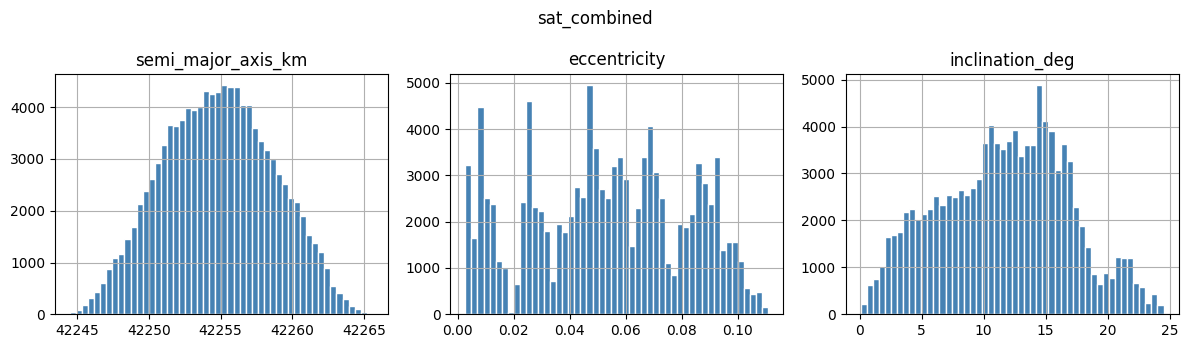

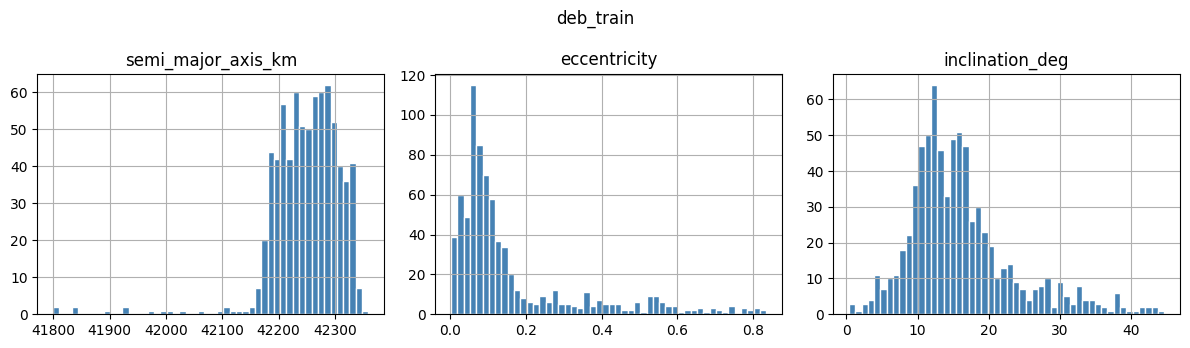

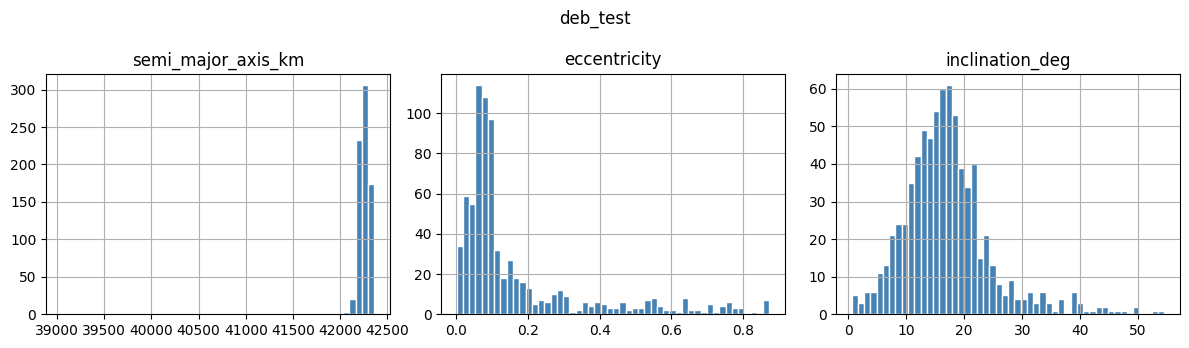

In [19]:
def hist_grid(df: pd.DataFrame, cols: list[str], title: str, bins: int = 50) -> None:
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5), squeeze=False)
    for ax, c in zip(axes[0], cols):
        df[c].dropna().hist(ax=ax, bins=bins, color="steelblue", edgecolor="white")
        ax.set_title(c)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


hist_grid(sat, ["semi_major_axis_km", "eccentricity", "inclination_deg"], "sat_combined")
hist_grid(deb_tr, ["semi_major_axis_km", "eccentricity", "inclination_deg"], "deb_train")
hist_grid(deb_te, ["semi_major_axis_km", "eccentricity", "inclination_deg"], "deb_test")

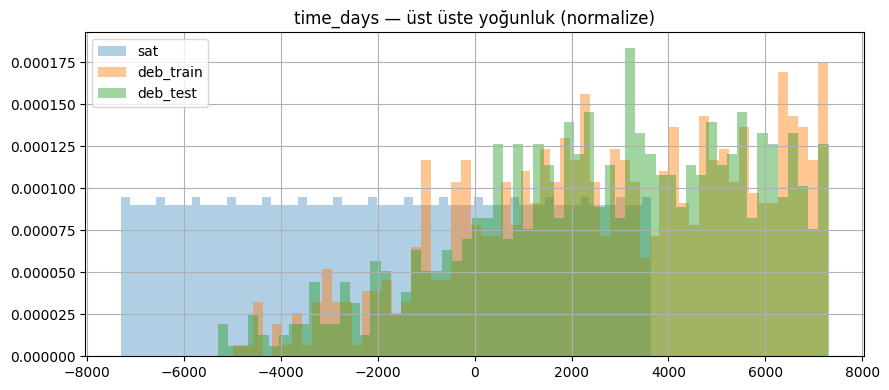

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
for df, lab, alpha in [(sat, "sat", 0.35), (deb_tr, "deb_train", 0.45), (deb_te, "deb_test", 0.45)]:
    ax.hist(df["time_days"].dropna(), bins=60, alpha=alpha, label=lab, density=True)
ax.set_title("time_days — üst üste yoğunluk (normalize)")
ax.legend()
plt.tight_layout()
plt.show()

### Kepler veri kümelerini tek tabloda birleştirme

`dataset` sütunu (`sat` / `deb_train` / `deb_test`) hangi CSV’den geldiğini ayırır. `tum_uzay_copleri` buraya eklenmez (farklı temsil ve anahtar yok).

In [21]:
kepler_all = pd.concat([sat, deb_tr, deb_te], ignore_index=True)
print("kepler_all:", kepler_all.shape, "| sütunlar:", list(kepler_all.columns))
display(kepler_all.groupby("dataset", observed=True)[KEPLER_NUM].describe().T)

kepler_all: (111102, 10) | sütunlar: ['dataset', 'source_file', 'obs_index', 'time_days', 'semi_major_axis_km', 'eccentricity', 'inclination_deg', 'raan_deg', 'arg_perigee_deg', 'mean_anomaly_deg']


dataset                       deb_test     deb_train            sat
time_days          count    751.000000    751.000000  109600.000000
                   mean    2728.209055   2803.268975   -1830.000000
                   std     2893.236196   2954.037587    3163.892592
                   min    -5305.000000  -4995.000000   -7305.000000
                   25%      800.000000    680.000000   -4567.500000
                   50%     3045.000000   2965.000000   -1830.000000
                   75%     5085.000000   5315.000000     907.500000
                   max     7305.000000   7295.000000    3645.000000
semi_major_axis_km count    751.000000    751.000000  109600.000000
                   mean   42217.945819  42248.736258   42254.834912
                   std      274.744473     63.774051       3.857942
                   min    39048.480000  41799.400000   42244.510000
                   25%    42211.900000  42213.780000   42251.980000
                   50%    42250.600000  42256.100000   42254.840000
                   75%    42292.970000  42289.670000   42257.610000
                   max    42362.720000  42359.700000   42265.600000
eccentricity       count    751.000000    751.000000  109600.000000
                   mean       0.166204      0.160289       0.053018
                   std        0.190103      0.175528       0.027985
                   min        0.000977      0.002100       0.002761
                   25%        0.058691      0.058139       0.029555
                   50%        0.088925      0.092304       0.053602
                   75%        0.176771      0.160691       0.073729
                   max        0.873696      0.834790       0.110802
inclination_deg    count    751.000000    751.000000  109600.000000
                   mean      17.107444     16.036327      11.635586
                   std        7.792857      7.514409       5.210860
                   min        0.590100      0.370700       0.086200
                   25%       12.405750     11.229600       7.699875
                   50%       16.340300     14.716800      11.925650
                   75%       20.354100     18.802600      15.320825
                   max       54.523100     44.607300      24.508400
raan_deg           count    751.000000    751.000000  109600.000000
                   mean     176.905342    179.833538     180.691204
                   std      102.997104    102.083097     103.877196
                   min        0.349200      0.201100       0.003700
                   25%       89.900150     98.177550      90.829600
                   50%      174.676200    175.068700     181.272100
                   75%      266.825650    263.531200     270.636175
                   max      360.617300    363.532500     359.998700
arg_perigee_deg    count    751.000000    751.000000  109600.000000
                   mean     178.803172    186.311948     182.342064
                   std      102.012635    106.655770     104.952402
                   min        2.068900      0.042200       0.009300
                   25%       91.752100     91.544150      90.120875
                   50%      176.622200    192.460900     184.293950
                   75%      269.289400    280.463900     273.196600
                   max      362.269300    363.370000     359.997300
mean_anomaly_deg   count    751.000000    751.000000  109600.000000
                   mean     191.183343    203.764910     109.895478
                   std      152.702767    151.005663     121.103114
                   min        0.071600      0.306300       0.001300
                   25%       24.535150     29.603300      25.281075
                   50%      297.111400    308.137700      54.649500
                   75%      337.659850    340.753350     136.481125
                   max      365.024000    366.156600     359.999700

## 2) `tum_uzay_copleri.csv` (anlık konum/hız)

- `copluk_kaynagi` frekansları
- Genel `describe`
- Kaynak grubuna göre özet
- Konum/hız histogramları (isteğe bağlı: hız büyüklüğü)

In [22]:
cop_path = ROOT / "tum_uzay_copleri.csv"
if not cop_path.exists():
    raise FileNotFoundError(cop_path)

cop = pd.read_csv(cop_path, encoding="utf-8-sig")
print(f"tum_uzay_copleri: {len(cop):,} satır, sütunlar: {list(cop.columns)}")

tum_uzay_copleri: 17,415 satır, sütunlar: ['isim', 'x_km', 'y_km', 'z_km', 'hiz_x_kms', 'hiz_y_kms', 'hiz_z_kms', 'copluk_kaynagi']


In [23]:
print("copluk_kaynagi — value_counts")
vc = cop["copluk_kaynagi"].value_counts(dropna=False)
display(vc.to_frame("adet"))
display((vc / vc.sum()).rename("oran").to_frame())

copluk_kaynagi — value_counts


,adet
copluk_kaynagi,
aktif_uydular,14878
fengyun_1c_copleri,1852
cosmos_2251_copleri,575
iridium_33_copleri,106
cosmos_1408_copleri,4


,oran
copluk_kaynagi,
aktif_uydular,0.854321
fengyun_1c_copleri,0.106345
cosmos_2251_copleri,0.033018
iridium_33_copleri,0.006087
cosmos_1408_copleri,0.000230


In [24]:
num_cop = [c for c in cop.columns if c != "copluk_kaynagi" and c != "isim"]
print("Sayısal sütunlar:", num_cop)
display(cop[num_cop].describe().T)

Sayısal sütunlar: ['x_km', 'y_km', 'z_km', 'hiz_x_kms', 'hiz_y_kms', 'hiz_z_kms']


,count,mean,std,min,25%,50%,75%,max
x_km,17415.0,218.564341,6923.291825,-42397.63,-3634.255,13.87,3647.075,66211.21
y_km,17415.0,142.112237,6963.633186,-70236.35,-3469.010,15.91,3511.390,57936.68
z_km,17415.0,61.070579,4611.318876,-34621.07,-3886.060,7.64,3950.225,51314.40
hiz_x_kms,17415.0,-0.020692,4.212224,-8.07,-3.580,-0.03,3.590,7.81
hiz_y_kms,17415.0,-0.041336,4.136402,-7.68,-3.510,-0.04,3.410,7.68
hiz_z_kms,17415.0,0.004026,4.501711,-7.65,-4.245,0.00,4.260,7.70


In [25]:
grp = cop.groupby("copluk_kaynagi", observed=True)
key_cols = [c for c in ["x_km", "y_km", "z_km", "hiz_x_kms", "hiz_y_kms", "hiz_z_kms"] if c in cop.columns]
print("Grup bazlı describe (seçili sütunlar) — satır sayısı çok olabilir")
display(grp[key_cols].describe().T)

Grup bazlı describe (seçili sütunlar) — satır sayısı çok olabilir


copluk_kaynagi   aktif_uydular  cosmos_1408_copleri  cosmos_2251_copleri  \
x_km      count   14878.000000             4.000000           575.000000   
          mean      271.077786         -1400.160000          -196.237478   
          std      7344.928867          3857.050488          3614.988170   
          min    -42397.630000         -5065.770000         -7497.100000   
          25%     -3784.285000         -4562.490000         -3000.555000   
          50%        54.190000         -1309.350000          -207.170000   
          75%      3837.675000          1852.980000          2474.530000   
          max     66211.210000          2083.830000          7232.080000   
y_km      count   14878.000000             4.000000           575.000000   
          mean      164.128072           827.030000           -72.755496   
          std      7370.681606          4087.584567          3863.046708   
          min    -70236.350000         -4139.180000         -7453.430000   
          25%     -3598.372500         -1609.370000         -3177.715000   
          50%        18.430000          1250.290000           -99.010000   
          75%      3601.405000          3686.690000          3045.470000   
          max     57936.680000          4946.720000          7392.960000   
z_km      count   14878.000000             4.000000           575.000000   
          mean       73.985479          -836.587500            65.560400   
          std      4545.376955          4990.713698          4773.801440   
          min    -34621.070000         -5058.620000         -7295.830000   
          25%     -3735.260000         -3561.252500         -4431.055000   
          50%         7.135000         -2310.960000            74.420000   
          75%      3835.767500           413.705000          4734.170000   
          max     51314.400000          6334.190000          7289.030000   
hiz_x_kms count   14878.000000             4.000000           575.000000   
          mean       -0.019749            -0.845000             0.152626   
          std         4.293141             3.181871             3.706712   
          min        -8.070000            -5.230000            -7.410000   
          25%        -3.760000            -1.900000            -2.665000   
          50%        -0.050000            -0.205000             0.220000   
          75%         3.780000             0.850000             2.890000   
          max         7.810000             2.260000             7.510000   
hiz_y_kms count   14878.000000             4.000000           575.000000   
          mean       -0.039615             1.532500            -0.033235   
          std         4.181769             4.548050             3.951579   
          min        -7.680000            -2.800000            -7.460000   
          25%        -3.630000            -2.185000            -3.210000   
          50%        -0.010000             1.590000            -0.430000   
          75%         3.510000             5.307500             3.150000   
          max         7.680000             5.750000             7.520000   
hiz_z_kms count   14878.000000             4.000000           575.000000   
          mean       -0.032198            -4.222500             0.316574   
          std         4.374031             4.484851             5.153306   
          min        -7.650000            -7.390000            -7.330000   
          25%        -4.160000            -6.932500            -4.810000   
          50%        -0.000000            -5.920000             0.340000   
          75%         4.090000            -3.210000             5.600000   
          max         7.700000             2.340000             7.310000   

copluk_kaynagi   fengyun_1c_copleri  iridium_33_copleri  
x_km      count         1852.000000          106.000000  
          mean           -55.680643          -49.429906  
          std           3497.557960         3924.297740  
          min          -7422.540000        

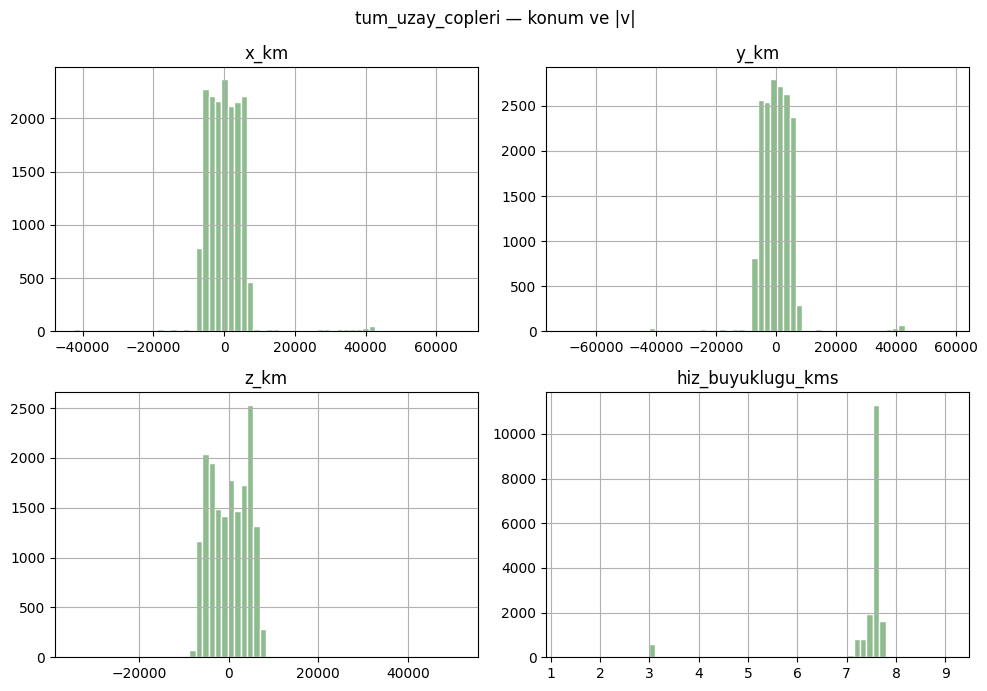

In [26]:
cop["hiz_buyuklugu_kms"] = (
    cop["hiz_x_kms"] ** 2 + cop["hiz_y_kms"] ** 2 + cop["hiz_z_kms"] ** 2
) ** 0.5

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()
for ax, col in zip(axes, ["x_km", "y_km", "z_km", "hiz_buyuklugu_kms"]):
    cop[col].dropna().hist(ax=ax, bins=60, color="darkseagreen", edgecolor="white")
    ax.set_title(col)
plt.suptitle("tum_uzay_copleri — konum ve |v|")
plt.tight_layout()
plt.show()

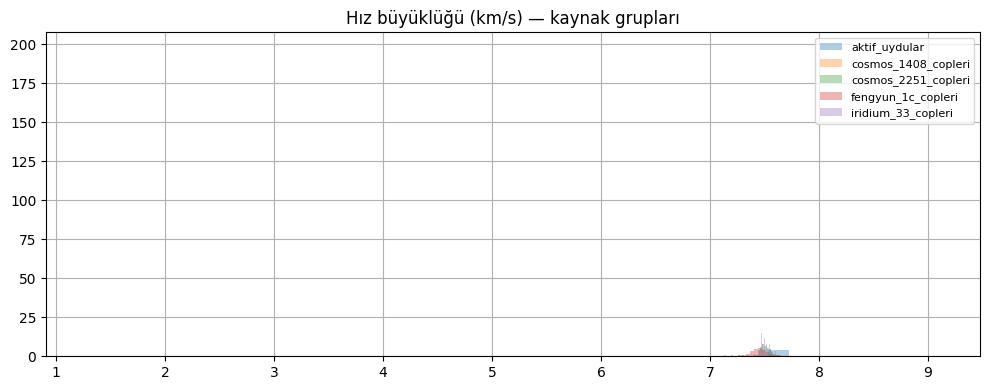

In [27]:
# Kaynak bazlı |v| dağılımı (üst üste)
fig, ax = plt.subplots(figsize=(10, 4))
for name, g in cop.groupby("copluk_kaynagi"):
    if len(g) < 2:
        continue
    ax.hist(g["hiz_buyuklugu_kms"], bins=40, alpha=0.35, label=str(name), density=True)
ax.set_title("Hız büyüklüğü (km/s) — kaynak grupları")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()